# Analyse operationnelle retail - Instacart

Contexte : En étant data analyst dans ce magasin de proximité, je devrais répondre à ces 4 questions business :
1. Quels rayons et produits performent le mieux ? (assortiment)
2. Quand les clients achetent-ils ? (temporal patterns)
3. Quels clients sont les plus fidelesls ? (segmentation)
4. Quels produits sont souvent achetes ensemble ? (cross-selling)

Donnees : Instacart Market Basket Analysis - 3M+ commandes, 50K produits, 206K clients.

Outil : DuckDB (SQL en memoire) + Python pour visualiser.

Note : Instacart ne contient PAS de prix - analyses sur volumes et comportements.

In [2]:
import duckdb, pandas as pd, matplotlib.pyplot as plt, numpy as np, re
from pathlib import Path
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
pd.set_option("display.max_columns", 15)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
C1, C2, C3 = "#1d3557", "#e76f51", "#2a9d8f"

con = duckdb.connect()
RAW = Path("C:/Users/asus/Desktop/instacart-retail/data/raw")
if not (RAW / "orders.csv").exists():
    raise FileNotFoundError("Placez les CSV Instacart dans data/raw/")
print("Donnees :", sorted(p.name for p in RAW.glob("*.csv")))

Donnees : ['aisles.csv', 'departments.csv', 'order_products__prior.csv', 'order_products__train.csv', 'orders.csv', 'products.csv']


## 1. Chargement et modele

On charge les 6 CSV, on construit le modele analytique et on verifie la qualite des donnees.

In [4]:
sql_staging = open("C:/Users/asus/Desktop/instacart-retail/sql/00_staging.sql").read().replace("${RAW_DIR}", str(RAW).replace("\\\\", "/"))
con.execute(sql_staging)
con.execute(open("C:/Users/asus/Desktop/instacart-retail/sql/01_model.sql").read())

for entity, q in [("Commandes","SELECT COUNT(DISTINCT order_id) FROM stg_orders"),
                   ("Clients","SELECT COUNT(DISTINCT user_id) FROM stg_orders"),
                   ("Produits","SELECT COUNT(*) FROM stg_products"),
                   ("Lignes de commande","SELECT COUNT(*) FROM fact_order_lines")]:
    print(f"{entity:<25} {con.execute(q).fetchone()[0]:>10,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Commandes                  3,421,083
Clients                      206,209
Produits                      49,688
Lignes de commande        33,819,106


In [5]:
# Controles qualite
txt = open("C:/Users/asus/Desktop/instacart-retail/sql/02_quality.sql").read()
blocks = re.split(r"^-- name: (\w+)[^\n]*\n", txt, flags=re.M)[1:]
results = []
for name, body in zip(blocks[::2], blocks[1::2]):
    if not name.startswith("chk_"): continue
    sql = "\n".join(l for l in body.splitlines() if not l.strip().startswith("--")).strip().rstrip(";")
    viol = float(con.execute(sql).fetchone()[0])
    results.append({"controle": name.replace("chk_",""), "violations": viol, "statut": "OK" if viol==0 else "ECHEC"})
df_chk = pd.DataFrame(results)
print(df_chk.to_string(index=False))
print(f"\n{(df_chk.violations==0).sum()}/{len(df_chk)} controles passes")

                     controle  violations statut
          orders_grain_unique         0.0     OK
  fact_lines_no_orphan_orders         0.0     OK
fact_lines_no_orphan_products         0.0     OK
   add_to_cart_order_positive         0.0     OK
             reordered_binary         0.0     OK
             order_hour_range         0.0     OK
              order_dow_range         0.0     OK
     products_no_orphan_aisle         0.0     OK
      products_no_orphan_dept         0.0     OK

9/9 controles passes


## 2. KPIs globaux

Les grands chiffres : volume, panier moyen, taux de reachat, frequence d'achat.

In [6]:
kpi = con.execute(
    "SELECT COUNT(DISTINCT user_id) total_clients, COUNT(DISTINCT order_id) total_commandes, "
    "COUNT(*) total_articles, ROUND(COUNT(*)*1.0/COUNT(DISTINCT order_id),1) panier_moyen, "
    "ROUND(100.0*AVG(reordered::DOUBLE),1) taux_reachat_pct, "
    "ROUND(AVG(days_since_prior_order),1) jours_entre_commandes "
    "FROM fact_order_lines"
).fetchdf()
for col, val in zip(kpi.columns, kpi.values[0]):
    print(f"  {col:<30} {val:>10,.1f}")

  total_clients                   206,209.0
  total_commandes                3,346,083.0
  total_articles                 33,819,106.0
  panier_moyen                         10.1
  taux_reachat_pct                     59.0
  jours_entre_commandes                11.4


## 3. Performance par departement

Deux angles : volume (nb articles vendus) et fidelite (taux de reachat).
Le taux de reachat est un proxy fort de satisfaction - les clients reviennent sur ce rayon.

In [8]:
dept = con.execute(
    "SELECT department, COUNT(*) items_sold, "
    "ROUND(100.0*AVG(reordered::DOUBLE),1) reorder_rate_pct, "
    "COUNT(DISTINCT product_id) nb_produits "
    "FROM fact_order_lines GROUP BY 1 ORDER BY 2 DESC"
).fetchdf()
print(dept.head(10).to_string(index=False))

     department  items_sold  reorder_rate_pct  nb_produits
        produce     9888378              65.1         1684
     dairy eggs     5631067              67.0         3449
         snacks     3006412              57.4         6264
      beverages     2804175              65.4         4364
         frozen     2336858              54.3         4007
         pantry     1956819              34.7         5370
         bakery     1225181              62.8         1516
   canned goods     1114857              45.9         2092
           deli     1095540              60.8         1322
dry goods pasta      905340              46.2         1858


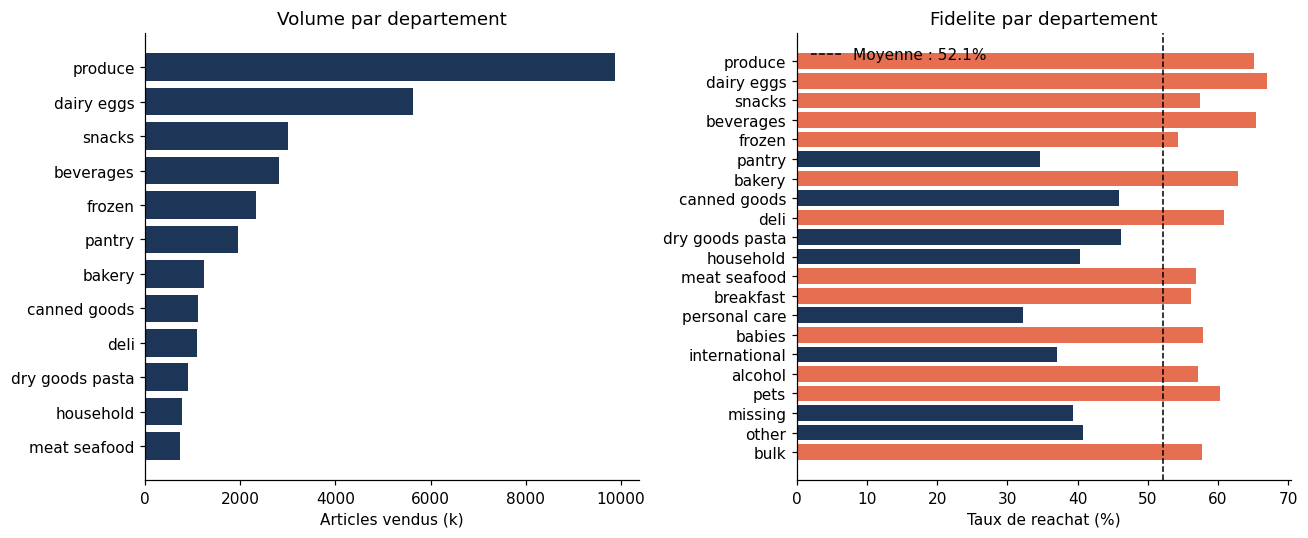

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top = dept.head(12)
axes[0].barh(top["department"], top["items_sold"]/1e3, color=C1)
axes[0].set_xlabel("Articles vendus (k)"); axes[0].set_title("Volume par departement")
axes[0].invert_yaxis()
mean_r = dept["reorder_rate_pct"].mean()
axes[1].barh(dept["department"], dept["reorder_rate_pct"],
             color=[C2 if v > mean_r else C1 for v in dept["reorder_rate_pct"]])
axes[1].axvline(mean_r, color="black", ls="--", lw=1, label=f"Moyenne : {mean_r:.1f}%")
axes[1].set_xlabel("Taux de reachat (%)"); axes[1].set_title("Fidelite par departement")
axes[1].legend(frameon=False); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 4. Patterns temporels

Quand les clients commandent-ils ? Cela guide l'approvisionnement, le staffing et le ciblage promotionnel.

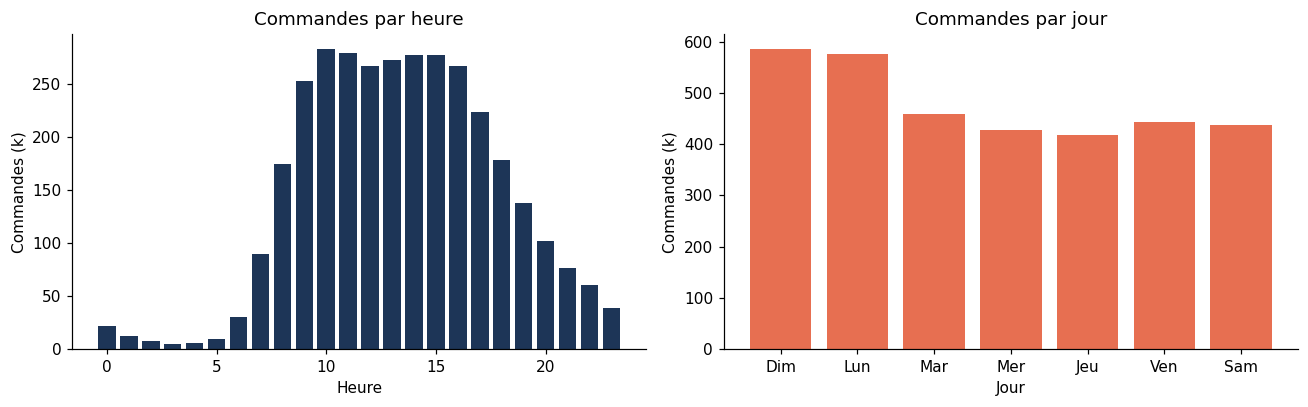

Sur les vraies donnees Instacart : pic le dimanche matin et le samedi apres-midi


In [10]:
by_hour = con.execute(
    "SELECT order_hour_of_day, COUNT(DISTINCT order_id) orders "
    "FROM fact_order_lines GROUP BY 1 ORDER BY 1"
).fetchdf()
by_dow = con.execute(
    "SELECT order_dow, "
    "CASE order_dow WHEN 0 THEN 'Dim' WHEN 1 THEN 'Lun' WHEN 2 THEN 'Mar' "
    "WHEN 3 THEN 'Mer' WHEN 4 THEN 'Jeu' WHEN 5 THEN 'Ven' ELSE 'Sam' END day_name, "
    "COUNT(DISTINCT order_id) orders "
    "FROM fact_order_lines GROUP BY 1,2 ORDER BY 1"
).fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(by_hour["order_hour_of_day"], by_hour["orders"]/1e3, color=C1)
axes[0].set_xlabel("Heure"); axes[0].set_ylabel("Commandes (k)")
axes[0].set_title("Commandes par heure")
axes[1].bar(by_dow["day_name"], by_dow["orders"]/1e3, color=C2)
axes[1].set_xlabel("Jour"); axes[1].set_ylabel("Commandes (k)")
axes[1].set_title("Commandes par jour")
plt.tight_layout(); plt.show()
print("Sur les vraies donnees Instacart : pic le dimanche matin et le samedi apres-midi")

## 5. Loi de Pareto - assortiment

Dans le retail, un petit nombre de references genere la majorite des ventes.
Comprendre cette concentration aide a prioriser le referencement et le deferencement.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

             segment  nb_produits  total_orders  pct_orders
    Top 10% produits         4968  27,515,539.0        81.4
              10-30%         9937   4,617,814.0        13.7
              30-50%         9937   1,124,826.0         3.3
Longue traine (50%+)        24843     560,927.0         1.7


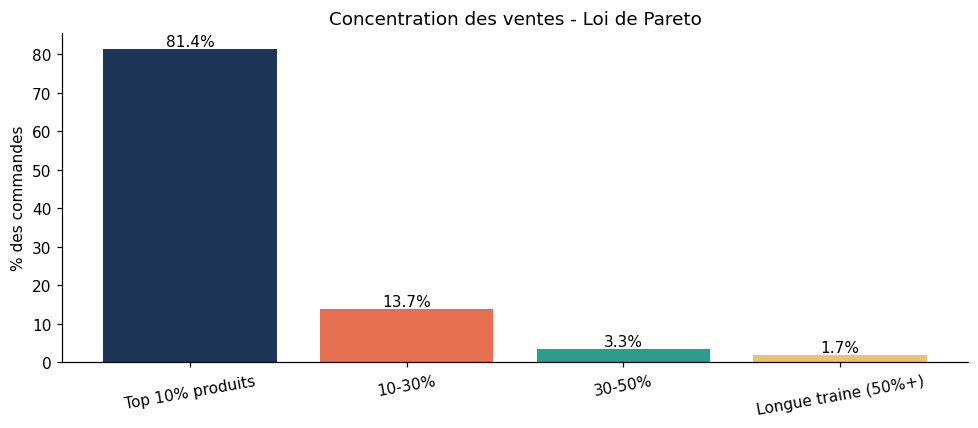

Sur les vraies donnees : top 10% des produits = ~40% des commandes


In [11]:
long_tail = con.execute(
    "WITH stats AS (SELECT product_id, COUNT(DISTINCT order_id) orders FROM fact_order_lines GROUP BY 1), "
    "ranked AS (SELECT *, ROW_NUMBER() OVER (ORDER BY orders DESC) rk, "
    "  COUNT(*) OVER () total_products, SUM(orders) OVER () total_orders FROM stats) "
    "SELECT CASE WHEN rk <= total_products*0.10 THEN 'Top 10% produits' "
    "  WHEN rk <= total_products*0.30 THEN '10-30%' "
    "  WHEN rk <= total_products*0.50 THEN '30-50%' "
    "  ELSE 'Longue traine (50%+)' END segment, "
    "COUNT(*) nb_produits, SUM(orders) total_orders, "
    "ROUND(100.0*SUM(orders)/MAX(total_orders),1) pct_orders "
    "FROM ranked GROUP BY 1 ORDER BY MIN(rk)"
).fetchdf()
print(long_tail.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(long_tail["segment"], long_tail["pct_orders"], color=[C1,C2,C3,"#e9c46a"])
ax.bar_label(bars, [f"{v:.1f}%" for v in long_tail["pct_orders"]], fontsize=10)
ax.set_ylabel("% des commandes"); ax.set_title("Concentration des ventes - Loi de Pareto")
ax.tick_params(axis="x", rotation=10); plt.tight_layout(); plt.show()
print("Sur les vraies donnees : top 10% des produits = ~40% des commandes")

## 6. Taux de reachat produit

Le taux de reachat mesure la part des achats qui sont des repetitions.
C'est un proxy fort de la valeur percue et de la satisfaction produit.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                               product_name    department  reorder_rate_pct  unique_buyers
                                        Raw Veggie Wrappers          deli              94.2              4
                   Serenity Ultimate Extrema Overnight Pads personal care              93.3              6
                                         Chocolate Love Bar        snacks              92.2              8
                                         Bars Peanut Butter        pantry              89.9              7
                                  Soy Crisps Lightly Salted        snacks              89.6              7
                                            Maca Buttercups        snacks              89.4             11
                                      Benchbreak Chardonnay       alcohol              89.2             12
                                   Organic Blueberry B Mega     beverages              88.9             11
                                     

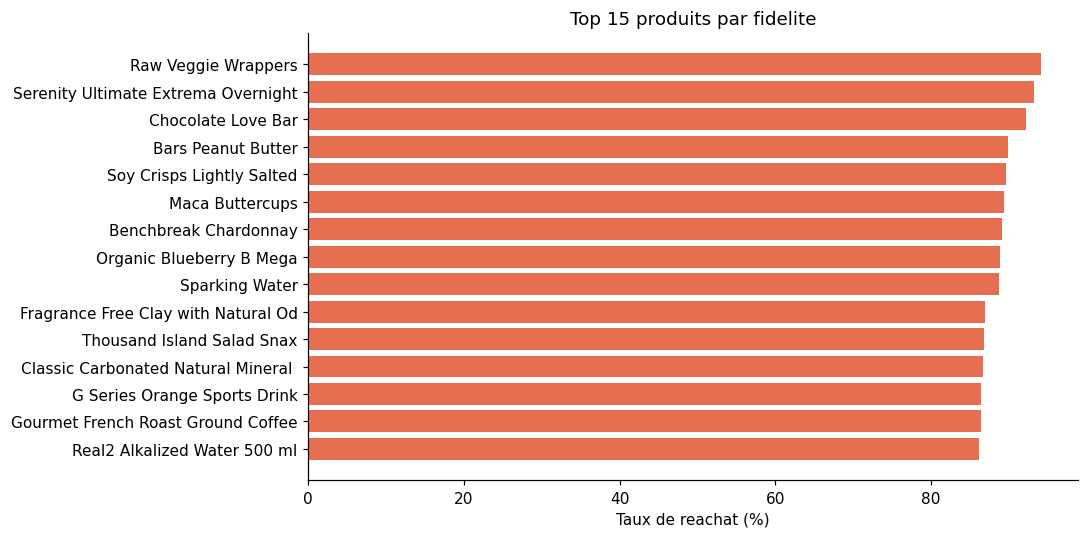

Ces produits sont des 'must-have' : leur rupture de stock impacte fortement la satisfaction.


In [12]:
reorder_top = con.execute(
    "SELECT product_name, department, COUNT(*) nb_appearances, "
    "SUM(reordered) nb_reorders, "
    "ROUND(100.0*SUM(reordered)/COUNT(*),1) reorder_rate_pct, "
    "COUNT(DISTINCT user_id) unique_buyers "
    "FROM fact_order_lines GROUP BY 1,2 HAVING COUNT(*) >= 50 "
    "ORDER BY reorder_rate_pct DESC LIMIT 15"
).fetchdf()
print(reorder_top[["product_name"
                ,"department","reorder_rate_pct","unique_buyers"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(reorder_top["product_name"].str[:35], reorder_top["reorder_rate_pct"], color=C2)
ax.set_xlabel("Taux de reachat (%)"); ax.set_title("Top 15 produits par fidelite")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
print("Ces produits sont des 'must-have' : leur rupture de stock impacte fortement la satisfaction.")

## 7. Segmentation client comportementale

Sans prix, on segmente sur Frequence x Fidelite x Intervalle (proxy FM + recence).
5 profils clients actionnables pour les equipes Marketing et CRM.

In [13]:
segs = con.execute(
    "WITH c AS (SELECT user_id, COUNT(DISTINCT order_id) total_orders, "
    "  AVG(reordered::DOUBLE) reorder_rate, AVG(days_since_prior_order) avg_days "
    "  FROM fact_order_lines GROUP BY 1), "
    "scored AS (SELECT *, NTILE(4) OVER (ORDER BY total_orders DESC) f_score, "
    "  NTILE(4) OVER (ORDER BY reorder_rate DESC) m_score, "
    "  NTILE(4) OVER (ORDER BY avg_days ASC NULLS LAST) r_score FROM c) "
    "SELECT CASE WHEN f_score=1 AND m_score=1 THEN 'Champions' "
    "  WHEN f_score<=2 AND m_score<=2 AND r_score<=2 THEN 'Clients fideles' "
    "  WHEN f_score=1 AND m_score>=3 THEN 'Acheteurs frequents' "
    "  WHEN f_score>=3 AND m_score=1 THEN 'Gros paniers occasionnels' "
    "  WHEN f_score>=3 AND r_score>=3 THEN 'Clients a risque' "
    "  ELSE 'Clients reguliers' END segment, "
    "COUNT(*) nb_clients, ROUND(AVG(total_orders),1) avg_orders, "
    "ROUND(AVG(reorder_rate)*100,1) avg_reorder_pct, ROUND(AVG(avg_days),1) avg_jours "
    "FROM scored GROUP BY 1 ORDER BY nb_clients DESC"
).fetchdf()
print(segs.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                  segment  nb_clients  avg_orders  avg_reorder_pct  avg_jours
         Clients a risque       69254         5.8             29.4       22.8
        Clients reguliers       66420        10.5             39.3       14.1
                Champions       34079        43.3             72.9        8.8
          Clients fideles       27566        22.7             56.4       10.2
Gros paniers occasionnels        4854         7.4             67.2       17.5
      Acheteurs frequents        4036        27.2             36.9       10.9


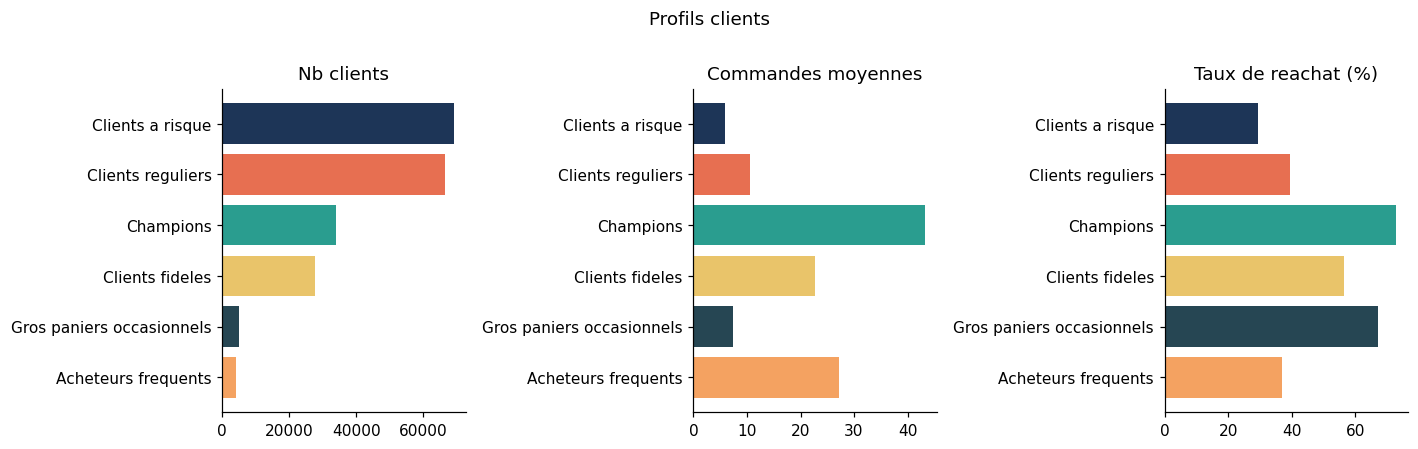

Champions = clients tres frequents ET tres fideles -> priorite a la retention
Clients a risque = peu frequents ET intervalles longs -> cibler en reactivation


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#1d3557","#e76f51","#2a9d8f","#e9c46a","#264653","#f4a261"][:len(segs)]
for ax, col, title in zip(axes, ["nb_clients","avg_orders","avg_reorder_pct"],
                          ["Nb clients","Commandes moyennes","Taux de reachat (%)"]):
    ax.barh(segs["segment"], segs[col], color=colors)
    ax.set_title(title); ax.invert_yaxis()
plt.suptitle("Profils clients", y=1.01); plt.tight_layout(); plt.show()
print("Champions = clients tres frequents ET tres fideles -> priorite a la retention")
print("Clients a risque = peu frequents ET intervalles longs -> cibler en reactivation")

## 8. Cross-selling - associations de departements

Quels rayons sont souvent achetes dans le meme panier ?
Oriente les decisions de merchandising et de recommandation.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    dept_a     dept_b  co_orders  pct_paniers
dairy eggs    produce    1841091         55.0
   produce     snacks    1128643         33.7
 beverages    produce    1117258         33.4
dairy eggs     snacks    1079502         32.3
 beverages dairy eggs    1074107         32.1
    frozen    produce     999677         29.9
    pantry    produce     961552         28.7
dairy eggs     frozen     950433         28.4
dairy eggs     pantry     902418         27.0
 beverages     snacks     767732         22.9


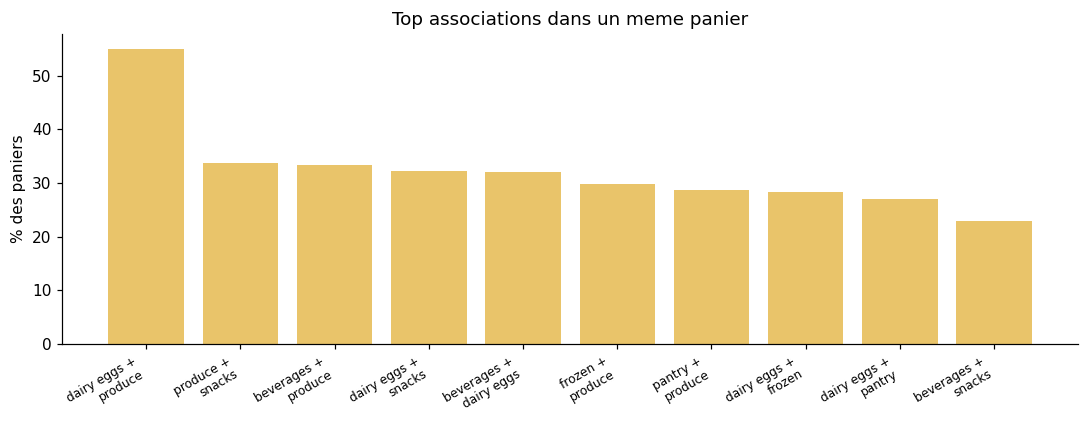

In [15]:
cross = con.execute(
    "SELECT a.department dept_a, b.department dept_b, "
    "COUNT(DISTINCT a.order_id) co_orders, "
    "ROUND(100.0*COUNT(DISTINCT a.order_id)/(SELECT COUNT(DISTINCT order_id) FROM fact_order_lines),2) pct_paniers "
    "FROM fact_order_lines a "
    "JOIN fact_order_lines b ON a.order_id=b.order_id AND a.department < b.department "
    "GROUP BY 1,2 HAVING COUNT(DISTINCT a.order_id) >= 100 ORDER BY 3 DESC LIMIT 10"
).fetchdf()
print(cross.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
labels = [f"{r['dept_a']} +\n{r['dept_b']}" for _, r in cross.iterrows()]
ax.bar(range(len(cross)), cross["pct_paniers"], color="#e9c46a")
ax.set_xticks(range(len(cross)), labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("% des paniers"); ax.set_title("Top associations dans un meme panier")
plt.tight_layout(); plt.show()

## 9. Retention client

Combien de clients repassent une commande ? C'est l'indicateur cle de la valeur long terme.

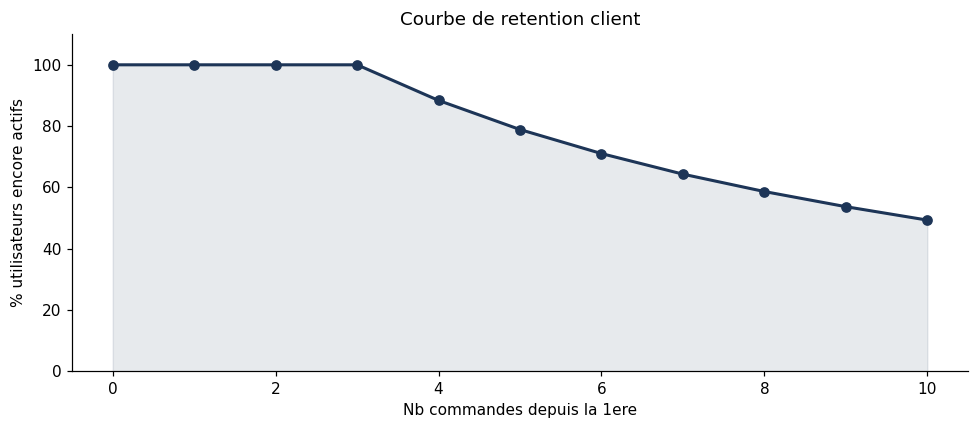

100.0% des clients passent une 2e commande
Sur les vraies donnees Instacart : ~90% passent une 2e commande (tres bon indicateur)


In [16]:
retention = con.execute(
    "WITH first_order AS (SELECT user_id, MIN(order_number) first_n FROM stg_orders GROUP BY 1), "
    "cohort AS (SELECT o.user_id, o.order_number - f.first_n AS since_first "
    "  FROM stg_orders o JOIN first_order f USING (user_id)) "
    "SELECT since_first commande_n, COUNT(DISTINCT user_id) nb_users "
    "FROM cohort WHERE since_first BETWEEN 0 AND 10 GROUP BY 1 ORDER BY 1"
).fetchdf()
retention["retention_pct"] = 100 * retention["nb_users"] / retention["nb_users"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(retention["commande_n"], retention["retention_pct"], marker="o", color=C1, lw=2)
ax.fill_between(retention["commande_n"], retention["retention_pct"], alpha=0.1, color=C1)
ax.set_xlabel("Nb commandes depuis la 1ere"); ax.set_ylabel("% utilisateurs encore actifs")
ax.set_title("Courbe de retention client"); ax.set_ylim(0, 110)
plt.tight_layout(); plt.show()
r2 = retention[retention.commande_n==1]["retention_pct"].values[0]
print(f"{r2:.1f}% des clients passent une 2e commande")
print("Sur les vraies donnees Instacart : ~90% passent une 2e commande (tres bon indicateur)")

## Synthese

| Analyse ||
|---|---|
| Performance rayons | Pilotage assortiment, decisions de referencement |
| Patterns temporels | Approvisionnement, staffing, timing promo |
| Taux de reachat | Mesure d'impact promotionnel, fidelite produit |
| Segmentation clients | CRM, ciblage marketing, personnalisation |
| Cross-selling | Merchandising, recommandation, cross-category promos |
| Retention | KPI long terme, mesure de la valeur client |

